In [1]:
# В ДАННОМ ПРОЕКТЕ РЕАЛИЗУЕТСЯ ШАБЛОН ДЛЯ УДОБНОГО ПРОЕКТИРОВАНИЯ СОБСТВЕННЫХ НЕЙРОСЕТЕЙ. 
# Данный шаблон представляет из себя набор классов, инкапсулируещих в себе ту или иную часть функционала нейронной сети, что в совокупности позволяет легко создавать даже многослойные нейронные сети,
# буквально одной строчкой добавляя в сеть слои и настроивая их параметры, конфигурации и работу самого слоя (то есть то, какой функционал включать в данном слое, например - нужно ли в данном конкретном свёрточном слое включать пулинг)
# При этом процесс обучения нейросети также, более менее, автоматизирован и унифицирован - то есть, 
# применяя данный шаблон, можно вообще не заботиться о написании кода для функций самой сети (ну точнее один раз пишешь 
# реализацию конкретного алгоритма неёросети, а дальше просто подключаешь его!) и забыть про описание процесса её обучения - 
# просто коротко, по шаблону описываешь все интерисующие тебя параметры нейросети, её конфигурации и слои, а затем запускаешь проект!


In [2]:
#Environment:

import sys
import random
import numpy as np
import math
import matplotlib as mtl
import matplotlib.pyplot as plt 

np.random.seed(1)

In [3]:
#Данные для тестирования работоспособности архитектуры шаблона:

In [4]:
#Declaration learning data:

trainingNumberOne_1 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberOne_2 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberOne_3 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberOne_4 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberOne_5 = np.array([ #Есть шумы
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
                      1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
                      0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberOne_6 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberOne_7 = np.array([ #Есть шумы
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
                      0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

trainingNumberTwo_1 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberTwo_2 = np.array([
                      1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
                      1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1,
                      1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
                      1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
                      0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1,
                      0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
                      1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
                      1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberTwo_3 = np.array([#Есть шумы
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberTwo_4 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberTwo_5 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberTwo_6 = np.array([  #Есть шумы
                      1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1,
                      1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0,
                      1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
                      0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
                      1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberTwo_7 = np.array([ #Есть шумы
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0,
                      0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
                      0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
    
trainingNumberThree_1 = np.array([
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberThree_2 = np.array([
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberThree_3 = np.array([  #Есть шумы
                      1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
                      1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
                      1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
                      1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
                      1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberThree_4 = np.array([
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberThree_5 = np.array([
                      0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberThree_6 = np.array([ #Есть помехи
                      1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
                      1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
                      1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
                      1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
                      1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
                      1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberThree_7 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

trainingNumberFour_1 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberFour_2 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberFour_3 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberFour_4 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberFour_5 = np.array([ #Есть помехи
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1,
                      0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1,
                      0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
                      0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
                      0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
                      0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
                      1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberFour_6 = np.array([ #Есть помехи
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
                      0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1,
                      0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0,
                      0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
                      0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
                      1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
                      1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberFour_7 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
    
trainingNumberFive_1 = np.array([
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberFive_2 = np.array([
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberFive_3 = np.array([ #Есть помехи
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
                      0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])   
trainingNumberFive_4 = np.array([
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberFive_5 = np.array([
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberFive_6 = np.array([ #Есть помехи
                      1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
                      1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,
                      1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1,
                      1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
                      1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
                      1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberFive_7 = np.array([
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
    
trainingNumberSix_1 = np.array([
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberSix_2 = np.array([
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberSix_3 = np.array([
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])   
trainingNumberSix_4 = np.array([ # Есть помехи
                      1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1,
                      1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
                      0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberSix_5 = np.array([
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
                      0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberSix_6 = np.array([ # Есть помехи
                      1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1,
                      1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1,
                      0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
                      0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
                      1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
                      1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberSix_7 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
        
trainingNumberSeven_1 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberSeven_2 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberSeven_3 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])       
trainingNumberSeven_4 = np.array([
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberSeven_5 = np.array([ #Есть помехи
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberSeven_6 = np.array([  #Есть помехи
                      0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
                      1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
                      1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0,
                      1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
                      1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
                      1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1,
                      1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberSeven_7 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
    
trainingNumberEight_1 = np.array([
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberEight_2 = np.array([
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberEight_3 = np.array([
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberEight_4 = np.array([
                      0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberEight_5 = np.array([
                      0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 
                      0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 
                      1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 
                      1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 
                      1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 
                      1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 
                      0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 
                      0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 
                      0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 
                      1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 
                      1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 
                      1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 
                      0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 
                      0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberEight_6 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberEight_7 = np.array([ #Есть помехи
                      1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0,
                      1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
                      1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1,
                      1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
                      1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
                      1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
                      1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
    
trainingNumberNine_1 = np.array([
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberNine_2 = np.array([
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberNine_3 = np.array([
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])   
trainingNumberNine_4 = np.array([
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberNine_5 = np.array([ #Есть помехи
                      1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
                      1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
                      1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
                      1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0,
                      1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0,
                      1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberNine_6 = np.array([
                      0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
trainingNumberNine_7 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 
                      0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [5]:
#Forming learning dataset:

learnSetHorizontalSorted = np.array([trainingNumberOne_1, trainingNumberOne_2, trainingNumberOne_3, trainingNumberOne_4, trainingNumberOne_5, trainingNumberOne_6, trainingNumberOne_7,
                            trainingNumberTwo_1, trainingNumberTwo_2, trainingNumberTwo_3, trainingNumberTwo_4,  trainingNumberTwo_5, trainingNumberTwo_6, trainingNumberTwo_7,
                            trainingNumberThree_1, trainingNumberThree_2, trainingNumberThree_3, trainingNumberThree_4, trainingNumberThree_5, trainingNumberThree_6, trainingNumberThree_7,
                            trainingNumberFour_1, trainingNumberFour_2, trainingNumberFour_3, trainingNumberFour_4, trainingNumberFour_5, trainingNumberFour_6, trainingNumberFour_7,
                            trainingNumberFive_1, trainingNumberFive_2, trainingNumberFive_3, trainingNumberFive_4, trainingNumberFive_5, trainingNumberFive_6, trainingNumberFive_7,
                            trainingNumberSix_1, trainingNumberSix_2, trainingNumberSix_3, trainingNumberSix_4,  trainingNumberSix_5, trainingNumberSix_6, trainingNumberSix_7,
                            trainingNumberSeven_1, trainingNumberSeven_2, trainingNumberSeven_3, trainingNumberSeven_4, trainingNumberSeven_5, trainingNumberSeven_6, trainingNumberSeven_7,
                            trainingNumberEight_1, trainingNumberEight_2, trainingNumberEight_3, trainingNumberEight_4, trainingNumberEight_5, trainingNumberEight_6, trainingNumberEight_7,
                            trainingNumberNine_1, trainingNumberNine_2, trainingNumberNine_3, trainingNumberNine_4, trainingNumberNine_5, trainingNumberNine_6, trainingNumberNine_7])


#Более граммотно собранные для пакетного обучения данные (ну представь что у тебя при пакетном обучении нейронка будет обучаться лишь на один или пару выходных значений (как это было бы раньше))
learnSetVerticalSorted = np.array([trainingNumberOne_1, trainingNumberTwo_1, trainingNumberThree_1, trainingNumberFour_1, trainingNumberFive_1, trainingNumberSix_1, trainingNumberSeven_1, trainingNumberEight_1, trainingNumberNine_1,
                            trainingNumberOne_2, trainingNumberTwo_2, trainingNumberThree_2, trainingNumberFour_2, trainingNumberFive_2, trainingNumberSix_2, trainingNumberSeven_2, trainingNumberEight_2, trainingNumberNine_2,
                            trainingNumberOne_3, trainingNumberTwo_3, trainingNumberThree_3, trainingNumberFour_3, trainingNumberFive_3, trainingNumberSix_3, trainingNumberSeven_3, trainingNumberEight_3, trainingNumberNine_3,
                            trainingNumberOne_4, trainingNumberTwo_4, trainingNumberThree_4, trainingNumberFour_4, trainingNumberFive_4, trainingNumberSix_4, trainingNumberSeven_4, trainingNumberEight_4, trainingNumberNine_4,
                            trainingNumberOne_5, trainingNumberTwo_5, trainingNumberThree_5, trainingNumberFour_5, trainingNumberFive_5, trainingNumberSix_5, trainingNumberSeven_5, trainingNumberEight_5, trainingNumberNine_5,
                            trainingNumberOne_6, trainingNumberTwo_6, trainingNumberThree_6, trainingNumberFour_6, trainingNumberFive_6, trainingNumberSix_6, trainingNumberSeven_6, trainingNumberEight_6, trainingNumberNine_6,
                            trainingNumberOne_7, trainingNumberTwo_7, trainingNumberThree_7, trainingNumberFour_7, trainingNumberFive_7, trainingNumberSix_7, trainingNumberSeven_7, trainingNumberEight_7, trainingNumberNine_7])


#Ещё один вариант выборки - с ещё более случайным положением разных обучающих наборов:
learnSetUnsorted = np.array([trainingNumberOne_1, trainingNumberThree_5, trainingNumberThree_7, trainingNumberFour_6, trainingNumberFive_5, trainingNumberSix_4, trainingNumberSix_2, trainingNumberEight_2, trainingNumberNine_1,
                            trainingNumberTwo_2, trainingNumberOne_2, trainingNumberThree_2, trainingNumberFour_2, trainingNumberOne_6, trainingNumberSeven_3, trainingNumberSeven_2, trainingNumberEight_1, trainingNumberNine_2,
                            trainingNumberThree_3, trainingNumberTwo_3, trainingNumberOne_3, trainingNumberFour_3, trainingNumberFive_3, trainingNumberSix_3, trainingNumberSeven_1, trainingNumberNine_6, trainingNumberNine_3,
                            trainingNumberFour_4, trainingNumberTwo_4, trainingNumberThree_4, trainingNumberTwo_7, trainingNumberFive_4, trainingNumberSix_1, trainingNumberSeven_4, trainingNumberEight_4, trainingNumberNine_4,
                            trainingNumberFive_5, trainingNumberTwo_5, trainingNumberTwo_1, trainingNumberFour_5, trainingNumberOne_1, trainingNumberSix_5, trainingNumberSeven_5, trainingNumberEight_5, trainingNumberNine_5,
                            trainingNumberSix_6, trainingNumberTwo_6, trainingNumberThree_6, trainingNumberFour_1, trainingNumberNine_7, trainingNumberFive_2, trainingNumberSeven_6, trainingNumberEight_6, trainingNumberEight_3,
                            trainingNumberSeven_7, trainingNumberOne_4, trainingNumberThree_1, trainingNumberFour_7, trainingNumberFive_7, trainingNumberSix_7, trainingNumberOne_7, trainingNumberEight_7, trainingNumberFive_6])



learn_dataset = learnSetHorizontalSorted
#learn_dataset = learnSetVerticalSorted
#learn_dataset = learnSetUnsorted

In [6]:
#Forming test data set:

testNumberOne_1 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
testNumberOne_2 = np.array([
                      1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
testNumberOne_3 = np.array([
                      1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
                      1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1,
                      1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
                      1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
                      1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1,
                      1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1,
                      1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
                      1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
                      1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
                      1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
                      1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
                      1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
                      1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
                      1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

testNumberTwo_1 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
testNumberTwo_2 = np.array([
                      1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
testNumberTwo_3 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

testNumberThree_1 = np.array([
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
testNumberThree_2 = np.array([
                      1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
                      1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
testNumberThree_3 = np.array([
                      1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
                      1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

testNumberFour_1 = np.array([
                      1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
                      1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
testNumberFour_2 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0,
                      0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
                      1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
testNumberFour_3 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1,
                      0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1,
                      0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
                      1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
                      1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
                      1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
                      0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
    
testNumberFive_1 = np.array([
                      1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
                      1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
                      1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
                      1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1,
                      1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
testNumberFive_2 = np.array([
                      0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
testNumberFive_3 = np.array([
                      0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
                      1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0,
                      0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1,
                      1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
    
testNumberSix_1 = np.array([
                      0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0,
                      1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
                      0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
                      0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
testNumberSix_2 = np.array([
                      1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0,
                      0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
                      0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1,
                      0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
testNumberSix_3 = np.array([
                      0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1,
                      0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
        
testNumberSeven_1 = np.array([
                      0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1,
                      0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0,
                      1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0,
                      0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
testNumberSeven_2 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
                      0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
                      0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
                      1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
testNumberSeven_3 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
    
testNumberEight_1 = np.array([
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
testNumberEight_2 = np.array([
                      1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0,
                      1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
                      0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1,
                      0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0,
                      1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
testNumberEight_3 = np.array([
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
                      0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1,
                      0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1,
                      0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
    
testNumberNine_1 = np.array([
                      0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,
                      1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
                      1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
testNumberNine_2 = np.array([
                      0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
                      0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
                      0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1,
                      0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
                      0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
                      0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0,
                      0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
testNumberNine_3 = np.array([
                      0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1,
                      0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1,
                      0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1,
                      0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
                      0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0,
                      0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1,
                      0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0,
                      0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0,
                      0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0,
                      0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [7]:
test_dataset = np.array([testNumberOne_1, testNumberOne_2, testNumberOne_3,
                            testNumberTwo_1, testNumberTwo_2, testNumberTwo_3,
                            testNumberThree_1, testNumberThree_2, testNumberThree_3,
                            testNumberFour_1, testNumberFour_2, testNumberFour_3,
                            testNumberFive_1, testNumberFive_2, testNumberFive_3,
                            testNumberSix_1, testNumberSix_2, testNumberSix_3,
                            testNumberSeven_1, testNumberSeven_2, testNumberSeven_3,
                            testNumberEight_1, testNumberEight_2, testNumberEight_3,
                            testNumberNine_1, testNumberNine_2, testNumberNine_3])

In [8]:
#Declare right results for learning dataset:

resultsSetHorizontalSorted = np.array([1, 1, 1, 1, 1, 1, 1, 
                         2, 2, 2, 2, 2, 2, 2,
                         3, 3, 3, 3, 3, 3, 3, 
                         4, 4, 4, 4, 4, 4, 4,
                         5, 5, 5, 5, 5, 5, 5,
                         6, 6, 6, 6, 6, 6, 6,
                         7, 7, 7, 7, 7, 7, 7,
                         8, 8, 8, 8, 8, 8, 8,
                         9, 9, 9, 9, 9, 9, 9])

resultsSetVerticalSorted = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9,
                         1, 2, 3, 4, 5, 6, 7, 8, 9,
                         1, 2, 3, 4, 5, 6, 7, 8, 9,
                         1, 2, 3, 4, 5, 6, 7, 8, 9,
                         1, 2, 3, 4, 5, 6, 7, 8, 9,
                         1, 2, 3, 4, 5, 6, 7, 8, 9,
                         1, 2, 3, 4, 5, 6, 7, 8, 9])

resultsSetUnsorted = np.array([1, 3, 3, 4, 5, 6, 6, 8, 9, 
                         2, 1, 3, 4, 1, 7, 7, 8, 9,
                         3, 2, 1, 4, 5, 6, 7, 9, 9,
                         4, 2, 3, 2, 5, 6, 7, 8, 9,
                         5, 2, 2, 4, 1, 6, 7, 8, 9,
                         6, 2, 3, 4, 9, 5, 7, 8, 8,
                         7, 1, 3, 4, 5, 6, 1, 8, 9])


validResults = resultsSetHorizontalSorted
#validResults = resultsSetVerticalSorted
#validResults = resultsSetUnsorted


right_learning_res = np.zeros((len(validResults), 10)) 

for i, l in enumerate(validResults): 
    right_learning_res[i][l] = 1 

In [9]:
#Declare right results for testing dataset:

resultsSet = np.array([1, 1, 1,  
                             2, 2, 2,  
                             3, 3, 3,  
                             4, 4, 4,  
                             5, 5, 5,  
                             6, 6, 6,  
                             7, 7, 7, 
                             8, 8, 8,  
                             9, 9, 9])


right_test_results = np.zeros((len(resultsSet), 10)) 

    
for i, l in enumerate(resultsSet):
    right_test_results[i][l] = 1

In [10]:
#Сам шаблон нейросети:

In [11]:
#Activation functions:

def relu(inpt):
    return (inpt > 0) * inpt

def relu2deriv(inpt):
    return inpt > 0 


def tanh(inpt):
    return  np.tanh(inpt)

def tanh2deriv(output):
    return 1 - (output ** 2)


def sigmoid(inpt):
    return (1 / (1 + np.exp(-inpt)))

def sigmoid2deriv(output):
    return output * (1 - output)


def softmax(inpt):
    temp = np.exp(inpt)
    return temp / np.sum(temp, axis = 1, keepdims = True)

def softmax2deriv(results, trueResults):
    return results - trueResults

    
def softmax_stable(inpt):
    e_inpt = np.exp(inpt - np.max(inpt, axis = 1, keepdims = True))
    return e_inpt / e_inpt.sum(axis = 1, keepdims = True)

def softmax2deriv_stable(results, trueResults):
    return results - trueResults

In [12]:
#Math operations:

def find_divisors(num):
    divisors = []
    
    for i in range(1, int(num ** .5) + 1):
        if num % i == 0:
            divisors.append(i)
            
            if i != num // i:
                divisors.append(num // i)
    return divisors


def find_optimal_sides(num):
    divisors = find_divisors(num)
    divisors.sort()
    
    mid = len(divisors) // 2
    
    if len(divisors) % 2 == 0:
        a = divisors[mid - 1]
        b = divisors[mid]
    else:
        a = b = divisors[mid]
        
    return [a, b]


In [13]:
# Neural network's sub functions:

MAX_ABS_ACTIVATION = 50.0
MAX_ABS_DELTA = 5.0
MAX_ABS_GRADIENT = 1.0
MAX_ABS_WEIGHT = 5.0
DROPOUT_KEEP_PROB = 0.85


def stabilize_tensor(values, clip_value = MAX_ABS_ACTIVATION):
    values = np.nan_to_num(values, nan = 0.0, posinf = clip_value, neginf = -clip_value)
    return np.clip(values, -clip_value, clip_value)


def clip_gradient(values, clip_value = MAX_ABS_GRADIENT):
    values = np.nan_to_num(values, nan = 0.0, posinf = clip_value, neginf = -clip_value)
    return np.clip(values, -clip_value, clip_value)


def ensure_finite(values, tensor_name):
    if not np.all(np.isfinite(values)):
        raise FloatingPointError("Non-finite values in " + tensor_name)


def get_slices(inputData, kernel_rows, kernel_cols, stride):
    input_sects = list()
    
    for row_start in range(0, inputData.shape[2] - kernel_rows + 1, stride):
        for col_start in range(0, inputData.shape[3] - kernel_cols + 1, stride):
            sect = get_image_section(inputData, row_start, row_start + kernel_rows, col_start, col_start + kernel_cols)
            input_sects.append(sect)
    return input_sects
    
    
def regularization(layer_input):
        dropout_mask_ = (np.random.random(layer_input.shape) < DROPOUT_KEEP_PROB).astype(layer_input.dtype)
        stabilized = stabilize_tensor(layer_input)
        return [stabilize_tensor((stabilized * dropout_mask_) / DROPOUT_KEEP_PROB), dropout_mask_]
    
    
def find_exact_value(predictions): 
    exactNumber = 1
    exactValue = 0
        
    for i in range(len(predictions)):
        if(((exactValue - 1) ** 2) > ((predictions[i] - 1) ** 2)):
            exactNumber = i
            exactValue = predictions[i]
        
    return exactNumber

          
def select_deriv_activation(using_activation):
    if(using_activation == relu):
        return relu2deriv
    elif(using_activation == tanh):
        return tanh2deriv
    elif(using_activation == sigmoid):
        return sigmoid2deriv
    elif(using_activation == softmax):
        return softmax2deriv
    elif(using_activation == softmax_stable):
        return softmax2deriv_stable

        
def get_image_section(layer, row_from, row_to, col_from, col_to):
    if layer.ndim == 3:
        layer = layer.reshape(layer.shape[0], 1, layer.shape[1], layer.shape[2])
    
    return layer[:, :, row_from:row_to, col_from:col_to]


def printCurrentResults(predictions, rightResults, currentError, fullError):
    for i in range(len(predictions)):
        print("CURRENT VALUE: " + str(find_exact_value(rightResults[i])) + ";\nPREDICTION VALUE: " + str(find_exact_value(predictions[i])) + ";\nRESULT:  " + str(predictions))
    print("\n\nCURRENT ERRORS: " + str(currentError) + "\nFULL ERROR:" + str(fullError) + "\n")
    
def printCurrentResults(predictions, rightResults, currentError):
    print("CURRENT VALUE: " + str(find_exact_value(rightResults)) + ";\nPREDICTION VALUE: " + str(find_exact_value(predictions)) + ";\nRESULT:  " + str(predictions))
    print("\n\nCURRENT ERRORS: " + str(currentError) + "\n")
    print("TOTAL CURRENT ERROR: " + str(np.sum(currentError[0])) + "\n")

In [14]:
#The graphs of neural network errors (as a function of learning epochs):

class LearningErrorGraph: 
    def __init__(self, title = "Learning errors graphs"): 
        self.title_graph = title 
        self.errors = [] 
        self.ages = []

    def draw(self):  
        plt.figure(figsize = (8, 5)) 
        plt.title(label = self.title_graph)
        plt.plot(self.ages, self.errors) #На данном графике отрисовываются повекторно ошибки сразу всех выходов, в зависимости от эпох(итераций) - то есть это 2-ч мерная матрица, вектора которой содержат в себе ошибки каждого из выходов сети, в каждой конкретной точке отсчета (итерации, эпохи), причём каждый элемент этих векторов - один конкретный выход сети, а каждый вектор - одна кокретная эпоха(итерация или другая точка отсчёта)
        plt.show()
        print()

        
class RealTasksErrorGraph: 
    def __init__(self, title = "Error graph of real tasks"): 
        self.title_graph = title 
        self.errors = [] 
        self.tasks = []

    def draw(self):  
        plt.figure(figsize = (9, 6)) 
        plt.title(label = self.title_graph)
        plt.plot(self.tasks, self.errors)
        plt.show()
        print()
        

In [15]:
# Errors analisis functionality:

class ErrorsAccounter:
    def __init__(self):
        self.graphAverageErrors = LearningErrorGraph("Average errors in neural network training")
        self.graphTotalAverageErrors = LearningErrorGraph("Total average errors in neural network training")
        self.graphAccumErrors = LearningErrorGraph("Accumulate errors in neural network training")
        self.graphTotalAccumErrors = LearningErrorGraph("Total accumulate errors in neural network training")
        
        self.currentBatchErrors = 0
        self.accumAgeErrors = 0
        
        self.middleAgeErrors = 0
        self.full_errors = 0
        
        
    def _filling_graphs(self, current_age):
        self.graphAverageErrors.errors.append(self.middleAgeErrors)
        self.graphAverageErrors.ages.append(current_age)
        
        self.graphTotalAverageErrors.errors.append(np.sum(np.array(self.middleAgeErrors)))
        self.graphTotalAverageErrors.ages.append(current_age)
        
        
        accumAgeErrs = np.sum(self.accumAgeErrors, axis = 0)
        
        self.graphAccumErrors.errors.append(accumAgeErrs)
        self.graphAccumErrors.ages.append(current_age)
        
        self.graphTotalAccumErrors.errors.append(np.sum(np.array(accumAgeErrs)))
        self.graphTotalAccumErrors.ages.append(current_age)
        
        
    def accounting_batch_results(self, prediction, right_predictions):
        self.currentBatchErrors = (prediction - right_predictions) ** 2 
        self.accumAgeErrors += self.currentBatchErrors
        
    def accounting_age_results(self, len_dataset, age):
        self.middleAgeErrors = (np.sum(self.accumAgeErrors, axis = 0) / len_dataset)
        self.full_errors += self.middleAgeErrors
        
        self._filling_graphs(age)
        
        self.accumAgeErrors = 0
        
        
    def draw_graphs_errors(self):
        self.graphAverageErrors.draw()
        self.graphTotalAverageErrors.draw()
        self.graphAccumErrors.draw()
        self.graphTotalAccumErrors.draw()
        
    def print_total_errors(self):
        print("List full errors: " + str(self.full_errors))
        print("Full error: " + str(np.sum(self.full_errors)))  
        print("\n\n") 
        
    def print_lastBatch_errors(self):
        print("Last errors: " + str(self.middleAgeErrors))
        print("Full last error: " + str(np.sum(self.middleAgeErrors)))   
        print("\n\n")
        
        

In [16]:
# Direct signal propagation:

class Direct_Layer:
    net_type_ = "direct"
    
    
    def __init__(self, func_activation, input_rows, input_cols, size_layer):
        self.using_activation_ = func_activation
        self.deriv_activation_ = select_deriv_activation(self.using_activation_)
        self.input_rows_ = input_rows
        self.input_cols_ = input_cols
        self.out_size_ = size_layer
        self.out_side_1 = self.out_size_
        self.out_side_2 = 1
        self.result_ = []
        self.weights_ = 0.2 * np.random.random((self.input_rows_ * self.input_cols_, self.out_size_)) - 0.1 
        
        self.dropout_mask_ = []
        self.layer_result_ = []
        
    @classmethod    
    def configuration_init(cls, configs):
        return cls(configs.func_activation, configs.input_rows, configs.input_cols, configs.size_layer)
        
        
    def calc_result(self, input_data, need_regularize = False):
        #print("\nNEW DIRECT LAYER\n")
        
        linear_result = np.dot(input_data.reshape(-1, self.weights_.shape[0]), self.weights_)
        linear_result = stabilize_tensor(linear_result)
        self.result_ = stabilize_tensor(self.using_activation_(linear_result))
        self.dropout_mask_ = np.ones(self.result_.shape)
        
        if need_regularize == True:
            buffer = regularization(self.result_)
            self.result_ = stabilize_tensor(buffer[0])
            self.dropout_mask_ = buffer[1]
        
        ensure_finite(self.result_, "direct layer result")
        
        #print("Final direct result: \n"  + str(self.result_))
        #print("Final direct result shape: \n"  + str(self.result_.shape))
        #print("\n\n\n")
        
        return self.result_

In [17]:
# CNN Layer:

class CNN_Layer:
    net_type_ = "convolution"
    
    def __init__(self, func_activation, input_rows, input_cols, stride, padding_size, kernel_rows, kernel_cols, num_kernels, pooling_size, input_channels = 1):
        self.using_activation_ = func_activation
        self.deriv_activation_ = select_deriv_activation(self.using_activation_)
        self.input_rows_ = input_rows
        self.input_cols_ = input_cols
        self.input_channels_ = input_channels
        self.stride_ = stride
        self.padding_size_ = padding_size
        self.kernel_rows_ = kernel_rows
        self.kernel_cols_ = kernel_cols
        self.num_kernels_ = num_kernels
        self.result_ = []
        self.weights_ = 0.2 * np.random.random((self.input_channels_ * self.kernel_rows_ * self.kernel_cols_, self.num_kernels_)) - 0.1  
        
        self.map_side_1 = 0
        self.map_side_2 = 0
        self.pooling_size_  = pooling_size
        if pooling_size < 1:
            self.pooling_size_ = 1
        
        padded_rows = self.input_rows_ + (2 * self.padding_size_)
        padded_cols = self.input_cols_ + (2 * self.padding_size_)
        self.map_side_1 = ((padded_rows - self.kernel_rows_) // self.stride_) + 1
        self.map_side_2 = ((padded_cols - self.kernel_cols_) // self.stride_) + 1
        self.map_size_ = self.map_side_1 * self.map_side_2 * self.num_kernels_  
        
        self.out_feature_rows_ = math.ceil(self.map_side_1 / self.pooling_size_)
        self.out_feature_cols_ = math.ceil(self.map_side_2 / self.pooling_size_)
        self.out_channels_ = self.num_kernels_
        self.out_side_1 = self.out_feature_rows_
        self.out_side_2 = self.out_feature_cols_ * self.out_channels_
        self.out_size_ = self.out_side_1 * self.out_side_2 
        
        self.flattened_input_ = []
        self.dropout_mask_ = []
        self.pooling_boofer_ = []
        self.pooling_mask_ = []
        self.layer_result_ = []
        self.conv_result_ = []
        
    @classmethod    
    def configuration_init(cls, configs):
        return cls(configs.func_activation, configs.input_rows, configs.input_cols, configs.stride, configs.padding_size,
                      configs.kernel_rows, configs.kernel_cols, configs.num_kernels, configs.pooling_size, getattr(configs, "input_channels", 1))
        
    
    def recovery_members(self):
        self.pooling_mask_ = []
        self.pooling_boofer_ = []
        self.layer_result_ = []
        self.conv_result_ = []
    
    
    def pooling_processing(self, buffer_pooling):
        if self.pooling_size_ > 1:
            pooled = np.zeros((buffer_pooling.shape[0], buffer_pooling.shape[1], self.out_feature_rows_, self.out_feature_cols_))
            self.pooling_mask_ = np.zeros_like(buffer_pooling)
    
            for batch in range(buffer_pooling.shape[0]):
                for kernel in range(buffer_pooling.shape[1]):
                    out_row = 0
                    
                    for i in range(0, buffer_pooling.shape[2], self.pooling_size_):
                        out_col = 0
                        
                        for j in range(0, buffer_pooling.shape[3], self.pooling_size_):
                            matr_slice = buffer_pooling[batch, kernel, i:i+self.pooling_size_, j:j+self.pooling_size_]
                            max_index = np.unravel_index(np.argmax(matr_slice), matr_slice.shape)
                            current_row = max_index[0] + i
                            current_col = max_index[1] + j
                            
                            pooled[batch, kernel, out_row, out_col] = buffer_pooling[batch, kernel, current_row, current_col]
                            self.pooling_mask_[batch, kernel, current_row, current_col] = 1
                            out_col += 1
                        
                        out_row += 1
        else:
            pooled = np.array(buffer_pooling, copy = True)
            self.pooling_mask_ = np.ones(buffer_pooling.shape)
            
        self.pooling_boofer_ = pooled
        return self.pooling_boofer_
    
        
    def calc_result(self, input_data, need_regularize = False):
        self.recovery_members()
        
        if input_data.ndim == 3:
            input_data = input_data.reshape(input_data.shape[0], 1, input_data.shape[1], input_data.shape[2])
        
        #Padding:
        input_data = np.pad(input_data, ((0, 0), (0, 0), (self.padding_size_, self.padding_size_), (self.padding_size_, self.padding_size_)))
        
        #CNN processing:
        input_slices = get_slices(input_data, self.kernel_rows_, self.kernel_cols_, self.stride_)
        expanded_input = np.stack(input_slices, axis = 1)
        
        shape = expanded_input.shape
        flattened_input = expanded_input.reshape(shape[0] * shape[1], -1)
        self.flattened_input_ = flattened_input 
        
        CNN_result = flattened_input.dot(self.weights_)
        CNN_result = stabilize_tensor(CNN_result)
        CNN_result = CNN_result.reshape(shape[0], self.map_side_1, self.map_side_2, self.num_kernels_).transpose(0, 3, 1, 2)
        
        self.dropout_mask_ = np.ones(CNN_result.shape)
        if need_regularize == True:
            buffer = regularization(CNN_result)
            CNN_result = stabilize_tensor(buffer[0])
            self.dropout_mask_ = buffer[1]
        
        self.conv_result_ = np.array(CNN_result, copy = True)
        CNN_result = self.pooling_processing(CNN_result)
        CNN_result = stabilize_tensor(self.using_activation_(CNN_result))
        
        #Preparing result:
        self.result_ = np.array(CNN_result)
        ensure_finite(self.result_, "convolution layer result")
        
        return self.result_

In [18]:
# Neural network:

class NeuralNetwork:
    def __init__(self):
        self.network_input_ = []
        self.layers = []
        self.net_iterator_ = 0
    
    
    def add_layer(self, layer):
        self.layers.append(layer)
        
        
    def create_direction_layer(self, func_activation, size_layer, input_rows = 0, input_cols = 0):
        layer_num = len(self.layers)
        
        if layer_num != 0:
            last_layer = self.layers[layer_num - 1]
            self.layers.append(Direct_Layer(func_activation, last_layer.out_side_1, last_layer.out_side_2, size_layer))
        else:
            self.layers.append(Direct_Layer(func_activation, input_rows, input_cols, size_layer))
            
            
    def __creating_CNN_layer(self, func_activation, stride, padding_size, kernel_rows, 
                             kernel_cols, num_kernels, pooling_size, input_rows = 0, input_cols = 0):
        layer_num = len(self.layers)
        
        if layer_num != 0:
            last_layer = self.layers[layer_num - 1]
            
            if last_layer.net_type_ == "convolution":
                self.layers.append(CNN_Layer(func_activation, last_layer.out_feature_rows_, last_layer.out_feature_cols_, stride, padding_size, 
                                             kernel_rows, kernel_cols, num_kernels, pooling_size, last_layer.out_channels_))
            else:
                self.layers.append(CNN_Layer(func_activation, last_layer.out_side_1, last_layer.out_side_2, stride, padding_size, 
                                             kernel_rows, kernel_cols, num_kernels, pooling_size))
        else:
            self.layers.append(CNN_Layer(func_activation, input_rows, input_cols, stride, padding_size, 
                                         kernel_rows, kernel_cols, num_kernels, pooling_size))
            
            
            
    
    def create_CNN_layer(self, func_activation, kernel_rows, kernel_cols, num_kernels, stride, padding_size, input_rows = 0, input_cols = 0):
        self.__creating_CNN_layer(func_activation, stride, padding_size, kernel_rows, 
                                  kernel_cols, num_kernels, 0, input_rows, input_cols)
            
    def create_poolingCNN_layer(self, func_activation, kernel_rows, kernel_cols, num_kernels, stride, padding_size, pooling_size, input_rows = 0, input_cols = 0):
            self.__creating_CNN_layer(func_activation, stride, padding_size, kernel_rows,
                                      kernel_cols, num_kernels, pooling_size, input_rows, input_cols)
        
  
    def check_next_layer(self): 
        if(self.net_iterator_ + 1 >= self.num_layers()):
            return 0
        return 1
    
    def check_previous_layer(self): 
        if(self.net_iterator_ - 1 < 0):
            return 0
        return 1
        
        
    def num_layers(self):
        return len(self.layers)
    
        
    def go_output_layer(self):
        self.net_iterator_ = self.num_layers() - 1
        return self.layers[self.net_iterator_]
        
    def go_input_layer(self):
        self.net_iterator_ = 0
        return self.layers[self.net_iterator_]

    def go_next_layer(self): 
        self.net_iterator_ = self.net_iterator_ + 1
        
        if(self.net_iterator_ >= self.num_layers()):
            return 0
        return self.layers[self.net_iterator_]
    
    def go_previous_layer(self): 
        self.net_iterator_ = self.net_iterator_ - 1
        
        if(self.net_iterator_ < 0):
            return 0
        return self.layers[self.net_iterator_]

        
    def get_inputLayer_data(self):
        if(self.net_iterator_ < 1):
            return self.network_input_
        elif(self.layers[self.net_iterator_].net_type_ == "convolution"):
            return self.layers[self.net_iterator_].flattened_input_
        
        return self.layers[self.net_iterator_ - 1].result_
   
    def get_next_weights(self):
        if(self.net_iterator_ + 1 >= self.num_layers()):
            return 0
        return self.layers[self.net_iterator_ + 1].weights_
        
    def get_current_weights(self):
        if(self.net_iterator_ < 0 or self.net_iterator_ >= self.num_layers()):
            return 0
        return self.layers[self.net_iterator_].weights_
        
    def get_previous_weights(self):
        if(self.net_iterator_ - 1 < 0):
            return 0
        return self.layers[self.net_iterator_ - 1].weights_
        

    def get_next_layer(self):
        if(self.net_iterator_ + 1 >= self.num_layers()):
            return 0
        return self.layers[self.net_iterator_ + 1]
    
    def get_current_layer(self):
        if(self.net_iterator_ < 0 or self.net_iterator_ >= self.num_layers()):
            return 0
        return self.layers[self.net_iterator_]
    
    def get_previous_layer(self):
        if(self.net_iterator_ - 1 < 0):
            return 0
        return self.layers[self.net_iterator_ - 1]
    
    
    def get_network_copy(self):
        return self.layers
    
    

    def calc_prediction(self, input_data, need_regularize = False):
        self.network_input_ = input_data
        result = input_data
        
        for i in range(0, self.num_layers(), 1):
            if(i < self.num_layers() - 1):
                need_regularize = need_regularize
            else:
                need_regularize = False
                
            result = self.layers[i].calc_result(result, need_regularize)
            
        return result


In [19]:
# Neural network learning:

class Teacher:
    def __init__(self, batch_size = 1, alpha = 0.1):
        self.alpha_ = alpha
        self.batch_size = batch_size
        
        self.learnErrorsAccounter = ErrorsAccounter()
        
        
    def _checkTestSet(self, test_dataset, network, input_rows, input_cols): 
        input_data = test_dataset.reshape(test_dataset.shape[0], input_rows, input_cols)
        results = network.calc_prediction(input_data, True)
        
        return results
    
    
    def _transposed_convolution(self, featured_map, kernels, layer):
        if featured_map.ndim == 2:
            featured_map = featured_map.reshape(featured_map.shape[0], layer.num_kernels_, layer.map_side_1, layer.map_side_2)
        
        kernels = kernels.reshape(layer.input_channels_, layer.kernel_rows_, layer.kernel_cols_, layer.num_kernels_)
        padded_height = layer.input_rows_ + (2 * layer.padding_size_)
        padded_width = layer.input_cols_ + (2 * layer.padding_size_)
        result = np.zeros((featured_map.shape[0], layer.input_channels_, padded_height, padded_width))
        
        for batch in range(featured_map.shape[0]):
            for kernel in range(layer.num_kernels_):
                for i in range(layer.map_side_1):
                    row_start = i * layer.stride_
                    
                    for j in range(layer.map_side_2):
                        col_start = j * layer.stride_
                        result[batch, :, row_start:row_start + layer.kernel_rows_, col_start:col_start + layer.kernel_cols_] += featured_map[batch, kernel, i, j] * kernels[:, :, :, kernel]
        
        if layer.padding_size_ > 0:
            return result[:, :, layer.padding_size_:-layer.padding_size_, layer.padding_size_:-layer.padding_size_]
        
        return result
    
    
    def _reverse_pooling(self, layer, delta):
        if delta.ndim == 2:
            delta = delta.reshape(layer.result_.shape)
        
        if layer.pooling_size_ > 1:
            CNN_deltas = np.zeros_like(layer.pooling_mask_)
            
            for batch in range(layer.pooling_mask_.shape[0]):
                for kernel in range(layer.pooling_mask_.shape[1]):
                    out_row = 0
                    
                    for i in range(0, layer.pooling_mask_.shape[2], layer.pooling_size_):
                        out_col = 0
                        
                        for j in range(0, layer.pooling_mask_.shape[3], layer.pooling_size_):
                            mask_slice = layer.pooling_mask_[batch, kernel, i:i+layer.pooling_size_, j:j+layer.pooling_size_]
                            CNN_deltas[batch, kernel, i:i+layer.pooling_size_, j:j+layer.pooling_size_] = mask_slice * delta[batch, kernel, out_row, out_col]
                            out_col += 1
                        
                        out_row += 1
        else:
            CNN_deltas = delta.reshape(layer.pooling_mask_.shape)
    
        return CNN_deltas
    
    
    
    def start_learning(self, network, learn_dataset, right_results, input_rows, input_cols, ages = 1):
        self.ages_ = ages

        for age in range(0, self.ages_, 1):
            result = []
                    
            np.set_printoptions(threshold=sys.maxsize)
            print("Age: " + str(age + 1) + "/" + str(self.ages_))
        
            for batch in range(int(len(learn_dataset) / self.batch_size)):
                delta = []
                batch_start, batch_end = ((batch * self.batch_size), ((batch + 1) * self.batch_size))
                input_data = learn_dataset[batch_start:batch_end]
                input_data = input_data.reshape(input_data.shape[0], input_rows, input_cols)
                batch_right_results = right_results[batch_start:batch_end]
                batch_len = len(batch_right_results)
            
                result = stabilize_tensor(network.calc_prediction(input_data, True))
                ensure_finite(result, "network prediction")
            
                layer = network.go_output_layer()
                
                while layer != 0:
                    weights_update = []
                    
                    if network.check_next_layer() == 0:
                        delta = layer.deriv_activation_(result, batch_right_results) / batch_len
                        delta = stabilize_tensor(delta, MAX_ABS_DELTA)
                        previous_result = stabilize_tensor(network.get_inputLayer_data().reshape(result.shape[0], -1))
                        weights_update = previous_result.T.dot(delta)
                        
                    elif layer.net_type_ == "direct": 
                        delta = delta.dot(network.get_next_weights().T) * layer.deriv_activation_(layer.result_)
                        delta = stabilize_tensor(delta, MAX_ABS_DELTA)
                        delta *= layer.dropout_mask_.reshape(delta.shape)
                        
                        previous_result = stabilize_tensor(network.get_inputLayer_data().reshape(result.shape[0], -1))
                        weights_update = previous_result.T.dot(delta)
                        
                    elif layer.net_type_ == "convolution":
                        if network.get_next_layer().net_type_ == "convolution":
                            delta = self._transposed_convolution(delta, network.get_next_weights(), network.get_next_layer())
                        else:  
                            delta = delta.dot(network.get_next_weights().T).reshape(layer.result_.shape)
                        
                        delta = stabilize_tensor(delta, MAX_ABS_DELTA)
                        delta *= layer.deriv_activation_(layer.result_)
                        delta = self._reverse_pooling(layer, delta)
                        delta *= layer.dropout_mask_.reshape(delta.shape)
                        CNN_deltas = stabilize_tensor(delta, MAX_ABS_DELTA).transpose(0, 2, 3, 1).reshape(layer.flattened_input_.shape[0], layer.num_kernels_)
                        weights_update = layer.flattened_input_.T.dot(CNN_deltas)
                    
                    ensure_finite(delta, "delta")
                    weights_update = clip_gradient(weights_update)
                    ensure_finite(weights_update, "weights update")
                    
                    layer.weights_ -= self.alpha_ * weights_update
                    layer.weights_ = stabilize_tensor(layer.weights_, MAX_ABS_WEIGHT)
                    ensure_finite(layer.weights_, "layer weights")
                    
                    layer = network.go_previous_layer()
                    
                self.learnErrorsAccounter.accounting_batch_results(result, batch_right_results)
            
            self.learnErrorsAccounter.accounting_age_results(len(learn_dataset), age)
            
        self.learnErrorsAccounter.print_lastBatch_errors()
        self.learnErrorsAccounter.print_total_errors();
        self.learnErrorsAccounter.draw_graphs_errors();
        

In [20]:
# Configuration tables:

class DirectNerualConfigurations:
    def __init__(self):
        self.func_activation = 0
        self.input_rows = 0
        self.input_cols = 0
        self.size_layer = 0
    
    @classmethod    
    def init_configs(cls, func_activation, input_rows, input_cols, size_layer):
        obj = cls()
        obj.func_activation = func_activation
        obj.input_rows = input_rows
        obj.input_cols = input_cols
        obj.size_layer = size_layer
        return obj
        
    
    
class CNNConfigurations:
    def __init__(self):
        self.func_activation  = 0
        self.input_rows  = 0
        self.input_cols  = 0
        self.input_channels = 1
        self.stride  = 0
        self.padding_size = 0 
        self.kernel_rows  = 0
        self.kernel_cols  = 0
        self.num_kernels  = 0
        self.pooling_size = 0
    
    @classmethod    
    def init_configs(cls, func_activation, input_rows, input_cols, stride, padding_size, kernel_rows, kernel_cols, num_kernels, pooling_size, input_channels = 1):
        obj = cls()
        obj.func_activation = func_activation
        obj.input_rows = input_rows
        obj.input_cols = input_cols
        obj.input_channels = input_channels
        obj.stride = stride
        obj.padding_size = padding_size
        obj.kernel_rows = kernel_rows
        obj.kernel_cols = kernel_cols
        obj.num_kernels = num_kernels
        obj.pooling_size = pooling_size
        return obj
    

In [21]:
# Creating and setting configuration for neural network:
 
#Мини набор для тесту:
#learn_dataset = np.array([
#                        [[1, 2, 3, 34, 5, 6, 57, 8],
#                         [2, 3, 5, 8, 2, 3, 5, 8], 
#                         [8, 7, 6, 5, 4, 3, 2, 1], 
#                         [0, 1, 2, 33, 44, 61, 7, 9],
#                         [1, 1, 111, 1, 1, 21, 1, 1], 
#                         [2, 2, 2, 2, 2, 2, 2, 2], 
#                         [3, 43, 3, 3, 3, 3, 3, 23], 
#                         [7, 78, 7, 7, 37, 7, 7, 70]],
                        
#                        [[21, 78, 7, 7, 37, 7, 7, 70],
#                         [2, 3, 5, 8, 2, 3, 5, 8], 
#                         [8, 7, 6, 5, 4, 3, 2, 1], 
#                         [0, 1, 211, 33, 44, 61, 7, 9],
#                         [1, 1, 1, 1, 1, 1, 1, 1], 
#                         [2, 2, 2, 2, 2, 2, 2, 2], 
#                         [3, 43, 3, 3, 378, 3, 3, 23], 
#                         [1, 2, 3, 4, 5, 6, 7, 8]]
#                        ]) 
#right_learning_res = [[0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
#                      [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]]


#Так как слои прямого распространения неизбежно на выходе выдают просто вектор данных, лишённых даже признаков изначальной формы данных, 
# а именно эта форма и должна быть передана в свёрточный слой (она для него действительно важна! А размерность вектора, в качестве входных данных
# просто не подходит для алгоритма свёрточного слоя - ведь тогда окно пулинга получается размером n на 1 - а этого не должно быть и алгоритм на это не расчитан
# а потому просто произойдёт ошибка несовпадения размерностей!), то нельзя добавлять свёрточный слой после обычного слоя! Да и логически и теоритически
# и практически, должно быть наоборот - свёрточная нейронная сеть (как и реккурентная, как и большинство других видов нейронок) должны начинаться
# и состоять из спец слоёв (свёрточный например), а обычные слои, как раз являются выходными (можно сказать - слоями выходной части нейросети, 
# ведь слоёв прямого распространения в этой части может быть сразу несколько... в основном, только из таких слоёв эта часть сети и состоит!).
# Подытожим - нормально когда со спец слоёв начинается нейронная сеть и даже более того - если специ слои есть в нейросети, то с них она и начинается
# Также, нормально когда друг за другом, последовательно идут сразу несколько спец слоёв (несколько свёрточных слоёв), и даже больше -
# в целом допустимо, если последовательно друг за другом идут сразу несколько типов специ слоёв (свёрточные и реккурентные ... не понятно зачем это может быть нужно, но если нужно - ок)
# однако то, какую информацию принимают спец слои, следующие за текущими спец слоями, должно по форме и логически совпадать с тем, какие данные 
# выдаёт текущий тип спец слоёв (то есть нужно чётко понимать что данные находятся в ровно в тех позициях, в каких они должны находиться, чтобы
# следующий тип спец слоя мог их качественно обработать и найти нужные корреляции)!
# Обычные же слои прямого распространения сигнала - используются, как правило, именно для выхода сети(в качестве банального классификатора)
# и применять их посреди нейросети со спец слоями или же в начале не стоит!
#nn.create_poolingCNN_layer(1, 2, 2, 2, 2) #Размер сторон пулинга и окон свёртки должен быть меньше, либо равен сторонам входных данных (их походу придётся вручную прописывать и расчитывать)!
    
    
neural_net = NeuralNetwork()

# Конфигурация на 3 свёрточных слоя.
configs = CNNConfigurations.init_configs(
    func_activation = relu,
    input_rows = 15,
    input_cols = 15,
    stride = 1,
    padding_size = 1,
    kernel_rows = 6,
    kernel_cols = 6,
    num_kernels = 18,
    pooling_size = 0
)

# Первый свёрточный слой.
first_layer = CNN_Layer.configuration_init(configs)
neural_net.add_layer(first_layer)

# Второй свёрточный слой.
neural_net.create_CNN_layer(
    func_activation = relu,
    kernel_rows = 3,
    kernel_cols = 3,
    num_kernels = 12,
    stride = 1,
    padding_size = 1
)

# Третий свёрточный слой с pooling.
neural_net.create_poolingCNN_layer(
    func_activation = relu,
    kernel_rows = 3,
    kernel_cols = 3,
    num_kernels = 16,
    stride = 1,
    padding_size = 1,
    pooling_size = 2
)

# Классификатор.
neural_net.create_direction_layer(func_activation = relu, size_layer = 100)
neural_net.create_direction_layer(softmax_stable, size_layer = 10)

input_data = learn_dataset[0:1]
input_data = input_data.reshape(input_data.shape[0], 15, 15)

print("Result: " + str(neural_net.calc_prediction(input_data, True)))

Result: [[0.10802848 0.08200228 0.11512597 0.13061733 0.10607426 0.09690736
  0.12012482 0.06334621 0.08403989 0.09373341]]


Right result: [[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]
Prediction: [[0.09671891 0.10182753 0.09565642 0.0911816  0.12112262 0.08682426
  0.11773029 0.09142861 0.08438596 0.1131238 ]]




Age: 1/300
Age: 2/300
Age: 3/300
Age: 4/300
Age: 5/300
Age: 6/300
Age: 7/300
Age: 8/300
Age: 9/300
Age: 10/300
Age: 11/300
Age: 12/300
Age: 13/300
Age: 14/300
Age: 15/300
Age: 16/300
Age: 17/300
Age: 18/300
Age: 19/300
Age: 20/300
Age: 21/300
Age: 22/300
Age: 23/300
Age: 24/300
Age: 25/300
Age: 26/300
Age: 27/300
Age: 28/300
Age: 29/300
Age: 30/300
Age: 31/300
Age: 32/300
Age: 33/300
Age: 34/300
Age: 35/300
Age: 36/300
Age: 37/300
Age: 38/300
Age: 39/300
Age: 40/300
Age: 41/300
Age: 42/300
Age: 43/300
Age: 44/300
Age: 45/300
Age: 46/300
Age: 47/300
Age: 48/300
Age: 49/300
Age: 50/300
Age: 51/300
Age: 52/300
Age: 53/300
Age: 54/300
Age: 55/300
Age: 56/300
Age: 57/300
Age: 58/300
Age: 59/300
Age: 60/300
Age: 61/300
Age: 62/300
Age: 63/300
Age: 64/300
Age: 65/300
Age: 66/300
Age: 67/300
Age: 68/300
Age: 69/300
A

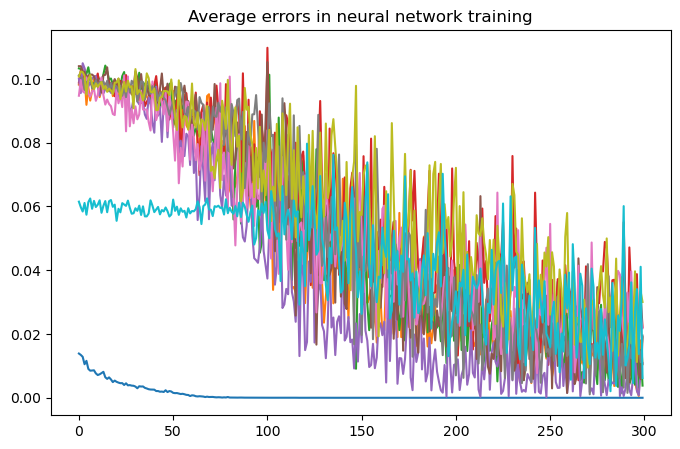

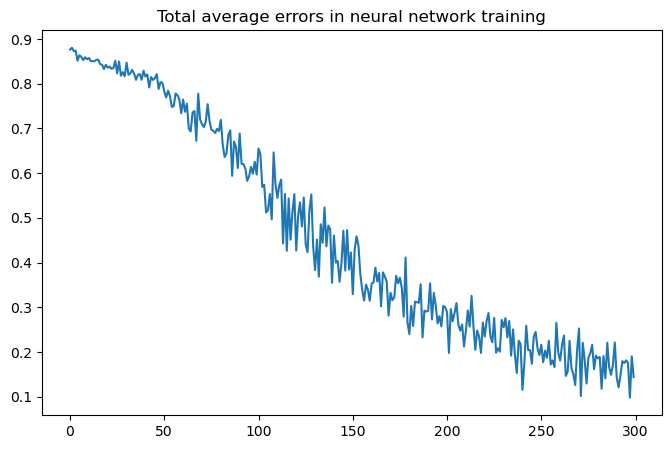

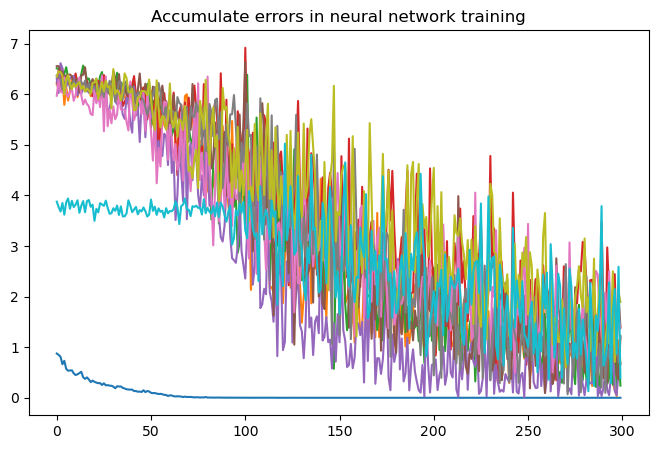

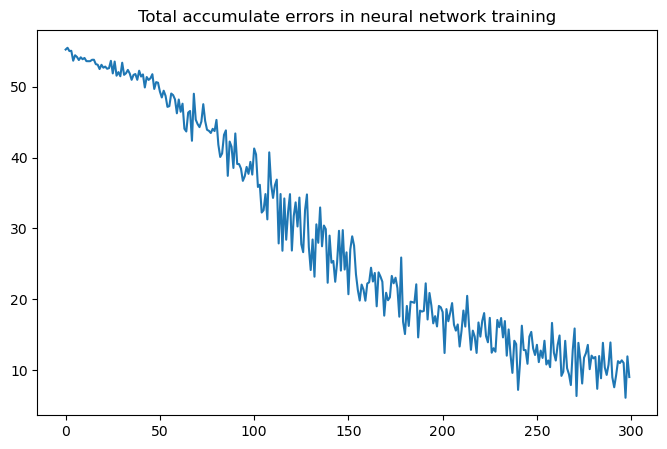


Right result: [[0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]]
Prediction: [[4.76120357e-08 9.97822010e-01 1.11024979e-03 2.72628655e-06
  1.00602977e-04 6.13762718e-04 1.66765622e-04 1.91530798e-05
  3.69609623e-07 1.64311838e-04]]


In [22]:
#  Learning process:

print("Right result: " + str(right_learning_res[0:1]))
print("Prediction: " + str(neural_net.calc_prediction(learn_dataset[0:1].reshape(1, 15, 15))))
print("\n\n\n")

learning = Teacher(batch_size = 5, alpha = 0.001)
learning.start_learning(neural_net, learn_dataset, right_learning_res, 15, 15, 300)


print("Right result: " + str(right_learning_res[0:1]))
print("Prediction: " + str(neural_net.calc_prediction(learn_dataset[0:1].reshape(1, 15, 15))))

In [23]:
# Neural network testing:
class Tester:
    def startTesting(self, network, test_dataset, right_test_results): # Данная функция просто оценивает результаты работы нейросети, на всём наборе тестовых данных - без эпох, просто, последовательно сами данные. Выводит при этом, различные параметры, по которым можно оценить эффективность работы(общая ошибка по всем выходам сети, получившиеся ошибки для текущего входного тестового элемента и т.д.), а также, отрисовывает графики величин выходных ошибок для каждого тестового входного элемента!!! 
        accumErrors = 0
        #graphErrors = GraphErrors("Errors in neural network training", "Errors of all outputs in neural network training")
        input_data = test_dataset.reshape(test_dataset.shape[0], network.go_input_layer().input_rows_, network.go_input_layer().input_cols_)
          
        for elem in range(len(test_dataset)):
            result = network.calc_prediction(input_data[elem:elem + 1], False)
            currentErrors = (result - right_test_results[elem]) ** 2
            
            accumErrors += currentErrors
            #graphErrors.errors.append(np.sum(currentErrors, axis = 0)) 
            #graphErrors.ages.append(elem)
            
            printCurrentResults(result[0], right_test_results[elem], currentErrors)
            print("\n\n")
        
        #graphErrors.printCheckingSubplots()
            
        print("List full errors: " + str(accumErrors) + "\n")
        print("Full error: " + str(np.sum(accumErrors)))
        
        
        
tester = Tester()
tester.startTesting(neural_net, test_dataset, right_test_results)

CURRENT VALUE: 1;
PREDICTION VALUE: 1;
RESULT:  [3.40344139e-08 9.97862308e-01 1.03799194e-03 2.43410635e-06
 6.61882025e-05 6.69669349e-04 2.00102152e-04 1.56789694e-05
 3.09379160e-07 1.45283512e-04]


CURRENT ERRORS: [[1.15834133e-15 4.56972556e-06 1.07742727e-06 5.92487374e-12
  4.38087815e-09 4.48457036e-07 4.00408712e-08 2.45830080e-10
  9.57154644e-14 2.11072988e-08]]

TOTAL CURRENT ERROR: 6.161390765250796e-06




CURRENT VALUE: 1;
PREDICTION VALUE: 1;
RESULT:  [1.04010521e-06 9.84027195e-01 4.66814819e-03 1.78714136e-05
 1.47764817e-03 2.47103697e-03 5.00643489e-03 6.82366937e-05
 1.99301291e-05 2.24245858e-03]


CURRENT ERRORS: [[1.08181885e-12 2.55130504e-04 2.17916075e-05 3.19387423e-10
  2.18344412e-06 6.10602372e-06 2.50643903e-05 4.65624636e-09
  3.97210046e-10 5.02862048e-06]]

TOTAL CURRENT ERROR: 0.00031530996392886116




CURRENT VALUE: 1;
PREDICTION VALUE: 1;
RESULT:  [1.27504011e-07 9.71598647e-01 1.14037541e-02 8.14984999e-05
 9.36321792e-05 1.58292545e-02 4.83512

In [24]:
#JUST FOR EXAMINATION!


alpha = 0.02
batchSize = 9
fullAgeError = 0
input_rows = 15
input_cols = 15
inputs_number = input_rows * input_cols
size_layer_1 = 111
size_layer_2 = 10

weights_0_1 = 0.2 * np.random.random((inputs_number, size_layer_1)) - 0.1
weights_1_2 = 0.2 * np.random.random((size_layer_1, size_layer_2)) - 0.1 
    


def processLearning(ages, learningDataset, rightTrainResults, weights_0_1, weights_1_2):
    full_errors = 0
    accumAgeErrors = 0
    middleAgeErrors = 0
    
    for age in range(ages):
        accumAgeErrors = 0
        
        for batch in range(int(len(learningDataset) / batchSize)):
            currentError = 0
            
            batch_start, batch_end = (batch * batchSize), ((batch + 1) * batchSize)
            input_data = learn_dataset[batch_start:batch_end]
            input_data = input_data.reshape(input_data.shape[0], input_rows, input_cols)
            
            
            #print("learningDataset: \n" + str(learningDataset[batch_start:batch_end]) + "\n")
            #print("learningDataset shape: " + str(learningDataset[batch_start:batch_end].shape) + "\n\n")
            
            #print("weights_0_1: \n" + str(weights_0_1) + "\n\n")
            #print("weights_0_1 shape: " + str(weights_0_1.shape) + "\n\n")
            
            #print("Input DATA: \n" + str(input_data) + "\n\n")
            #print("Input DATA shape: " + str(input_data.shape) + "\n\n")
            
            
            layer_1 = np.array(relu(np.dot(learningDataset[batch_start:batch_end], weights_0_1)))  
            dropout_mask = np.random.randint(2, size = layer_1.shape)
            #print("dropout_mask: \n" + str(dropout_mask) + "\n")
            #print("dropout_mask shape: \n" + str(dropout_mask.shape) + "\n")
            layer_1 *= dropout_mask * 2

            prediction = softmax(np.dot(layer_1, weights_1_2))
            
            
            layer_2_delta = softmax2deriv(prediction, rightTrainResults[batch_start:batch_end]) / batchSize    
            layer_1_delta = layer_2_delta.dot(weights_1_2.T) * relu2deriv(layer_1)
            layer_1_delta *= dropout_mask

            
            for k in range(batchSize):
                weights_1_2 -= np.dot(layer_1.T, layer_2_delta) * alpha
                weights_0_1 -= np.dot(np.array(learningDataset[batch_start:batch_end]).T, layer_1_delta) * alpha  
                
            
            currentError = (rightTrainResults[batch_start:batch_end] - prediction) ** 2
            accumAgeErrors += currentError
            
            
        middleAgeErrors = (accumAgeErrors / batchSize)
        full_errors += middleAgeErrors
        
        
    print("Last midle errors: " + str(middleAgeErrors))
    print("List full midle errors: " + str(full_errors))
    print("\nFull midle last error: " + str(np.sum(middleAgeErrors)))
    print("Full midle error: " + str(np.sum(full_errors)) + "\n\n\n")
            
            
processLearning(300, learn_dataset, right_learning_res, weights_0_1, weights_1_2)

Last midle errors: [[6.02704399e-06 1.78108234e-04 3.33138456e-04 5.13350663e-02
  1.31762569e-03 6.87111408e-06 1.27780011e-04 2.73091231e-02
  2.88245634e-04 4.46588262e-04]
 [2.06693684e-08 1.34010586e-02 2.67927072e-07 1.68831642e-06
  1.52458210e-06 6.89868558e-04 6.71152615e-03 1.32587327e-07
  1.52790775e-06 1.88802258e-04]
 [3.66024784e-08 1.60631936e-02 2.25576231e-03 9.41277678e-03
  1.15736820e-05 1.30457467e-02 2.81739821e-04 4.39978504e-03
  1.81350351e-04 5.42931979e-03]
 [7.33445917e-09 1.52299056e-03 3.52985606e-06 4.20042074e-06
  2.31832305e-03 7.03590228e-06 4.87685099e-05 4.52707083e-04
  1.70359631e-04 4.61340861e-04]
 [1.03551519e-08 4.67939937e-05 1.53462264e-05 2.79771263e-07
  1.32811466e-05 2.04565910e-06 2.81615880e-05 1.13264596e-05
  4.78369728e-05 2.45990145e-06]
 [3.16171975e-07 1.38966839e-04 2.86996792e-05 1.50618988e-03
  1.85672552e-04 1.72336576e-04 1.96438409e-03 4.72449297e-06
  3.03369228e-05 1.34288816e-03]
 [1.17889235e-09 1.96905404e-05 3.32763

In [25]:
print(str(learn_dataset.shape) + "\n\n\n")

layer_1 = np.array(relu(np.dot(learn_dataset[61:62], weights_0_1)))  
prediction = softmax(np.dot(layer_1, weights_1_2))

print("Result: " + str(prediction) + "\n\n")

(63, 225)



Result: [[2.52250819e-04 2.58485948e-03 1.26524249e-03 1.40967910e-02
  1.03963029e-03 3.62198741e-03 5.04286462e-03 1.52330540e-03
  3.66782694e-02 9.33894799e-01]]




In [26]:
#Transposed convolution testing:

def transposed_convolution(featured_map, kernels, padding = 0, stride = 1):
    featured_map = featured_map.reshape(featured_map.shape[0], 2, 3)
    kernels = kernels.reshape(kernels.shape[0], 2, 2)
    
    print(featured_map.shape)
    print("\n\n")
    
    
    map_height, map_width = featured_map[0].shape
    kernel_height, kernel_width = kernels[0].shape
    
    #Вычисляем размер входа:
    output_height = (map_height - 1) * stride + kernel_height - 2 * padding
    output_width = (map_width - 1) * stride + kernel_width - 2 * padding
    
    result = np.zeros((featured_map.shape[0], output_height, output_width))
    
    if padding > 0:
        result = np.pad(featured_map, padding, mode = 'constant', constant_values = 0)
    
    for kernel in range(kernels.shape[0]):
        for data in range(featured_map.shape[0]):
            for i in range(0, map_height, stride):
                for j in range(0, map_width, stride):
                    result[data, i:i+kernel_height, j:j+kernel_width] += featured_map[data, i, j] * kernels[kernel] 
                    
    return result.reshape(-1, output_height, output_width)


kernel = np.array([[[3, 1], 
                    [1, 5]]])
                    #[[2, -3], 
                    #[4, 1]]])

next_deltas = np.array([[
                        [2, 4, 3], 
                        [0, 1, 4]]])
                        #[[-1, 8], 
                        #[6, 0.]]])
#next_deltas = np.array([[-0.1]])

kernel = kernel.reshape(1, 1, -1)
next_deltas = next_deltas.reshape(1, 1, -1)

current_deltas = transposed_convolution(next_deltas, kernel)

print(current_deltas)
print(current_deltas.shape)

(1, 2, 3)



[[[ 6. 14. 13.  3.]
  [ 2. 17. 36. 19.]
  [ 0.  1.  9. 20.]]]
(1, 3, 4)
